## Trying to Fit an Ornstein Uhlenbeck Process to India VIX for regime detection

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

In [13]:
df = yf.download("^INDIAVIX", start="1900-01-01")['Close']
df.head()

[*********************100%***********************]  1 of 1 completed


Ticker,^INDIAVIX
Date,
2008-03-03,35.759998
2008-03-04,38.080002
2008-03-05,35.509998
2008-03-07,35.200001
2008-03-10,32.580002


<Axes: xlabel='Date'>

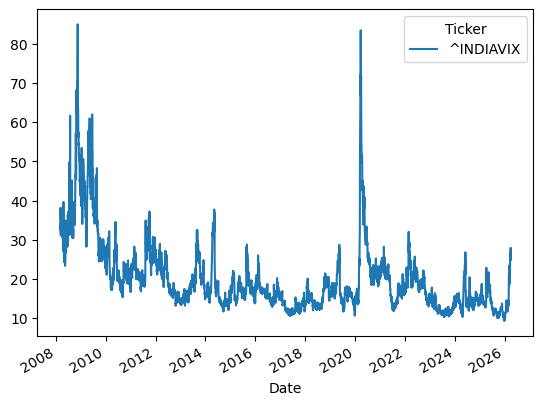

In [11]:
df.plot()

In [12]:
df.describe()

Ticker,^INDIAVIX
count,4429.000000
mean,19.833364
std,9.084282
min,9.150000
25%,14.110000
50%,17.070000
75%,22.150000
max,85.129997


In [42]:
# AR(1) OLS fit
X = df[df.columns[0]].values
beta, alpha = np.polyfit(X[:-1], X[1:], 1)

dt = 1/252
kappa = -np.log(beta) / dt
theta = alpha / (1 - beta)
resid = X[1:] - (alpha + beta * X[:-1])
sigma = resid.std() * np.sqrt(-2 * np.log(beta) / (dt * (1 - beta**2)))
sigma_eq = sigma / np.sqrt(2 * theta)

# Z-score today
z = (X[-1] - mu) / sigma_eq

half_life = np.log(2) / theta # in years
half_life_days = half_life * 252 

def expected_vix(X_t, mu, theta, s_days):
    s = s_days / 252
    return mu + (X_t - mu) * np.exp(-theta * s)

exp_vix_7d  = expected_vix(X[-1], mu, theta, 7)
exp_vix_15d = expected_vix(X[-1], mu, theta, 15)
exp_vix_30d = expected_vix(X[-1], mu, theta, 30)

print(f"AR(1) stats: alpha = {alpha} (intercept), beta = {beta} (coeff)")
print(f"OU stats: kappa = {kappa}, theta = {theta}, daily_vol = {sigma / np.sqrt(252)}")
print(f"sigma_eq = {sigma_eq:.4f}")  
print(f"Half-life = {half_life:.4f} years")
print(f"Half-life = {half_life_days:.2f} days")
print("-" * 15)
print(f"Today's VIX = {X[-1]}")
print(f"E[VIX | t+7d] = {exp_vix_7d:.4f}")
print(f"E[VIX | t+15d] = {exp_vix_15d:.4f}")
print(f"E[VIX | t+30d] = {exp_vix_30d:.4f}")
print("-" * 15)
print(f"Resid mean = {resid.mean():.6f}")
print(f"Resid std = {resid.std():.6f}")
print(f"R² = {1 - resid.var() / np.var(X[1:]):.6f}")

AR(1) stats: alpha = 0.3388207875187597 (intercept), beta = 0.9827989124441323 (coeff)
OU stats: kappa = 4.372387721081663, theta = 19.697637513808253, daily_vol = 1.6770786935839095
sigma_eq = 4.2416
Half-life = 0.0352 years
Half-life = 8.87 days
---------------
Today's VIX = 25.520000457763672
E[VIX | t+7d] = 23.0664
E[VIX | t+15d] = 21.5002
E[VIX | t+30d] = 20.2557
---------------
Resid mean = 0.000000
Resid std = 1.662634
R² = 0.966479


In [44]:
from statsmodels.tsa.stattools import adfuller
adf = adfuller(X)
print(f"ADF statistic : {adf[0]:.4f}")
print(f"p-value : {adf[1]:.4f}") 

ADF statistic : -4.1373
p-value : 0.0008


In [46]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm

y = X[1:]
x = sm.add_constant(X[:-1])
res = OLS(y, x).fit()
print(res.summary())
print(f"Durbin-Watson : {durbin_watson(res.resid):.4f}")  # want ≈ 2
lb = acorr_ljungbox(res.resid, lags=10)
print(lb)  # want p-values > 0.05

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                 1.276e+05
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:40:07   Log-Likelihood:                -8534.3
No. Observations:                4428   AIC:                         1.707e+04
Df Residuals:                    4426   BIC:                         1.709e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3388      0.060      5.646      0.0